In [30]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

GENERATED_DIR = Path.cwd() / "generated"

In [31]:
DURATION_DIR = GENERATED_DIR / "duration"
LINGUISTIC_DIR = GENERATED_DIR / "linguistic"

In [76]:
duration_paths = sorted(DURATION_DIR.glob("*"))[:5000] # Remove mean.npy and std.npy
linguistic_paths = sorted(LINGUISTIC_DIR.glob("*"))[:5000]
len(duration_paths), len(linguistic_paths)

(5000, 5000)

In [77]:
duration_arrays = [np.load(path) for path in duration_paths]
linguistic_arrays = [np.load(path) for path in linguistic_paths]

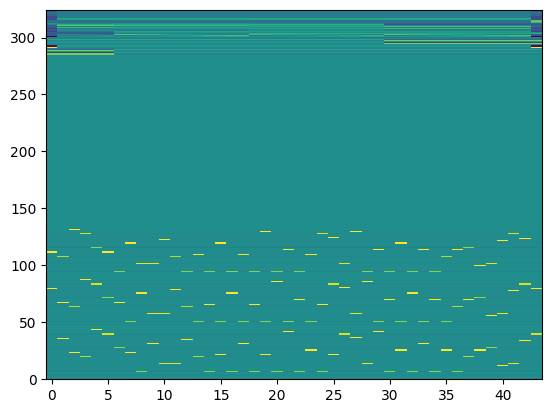

In [79]:
plt.imshow(linguistic_arrays[0].T, origin='lower', aspect='auto', interpolation='nearest')
plt.clim(-4, +4)

In [80]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64,),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dense(64,),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dense(64,),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dense(1, activation=None),
])

In [81]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              loss=tf.keras.losses.MeanSquaredError(),
              metrics=['MAE'])

In [82]:
dataset = tf.data.Dataset.from_tensor_slices(
    (np.concatenate(linguistic_arrays, axis=0), np.concatenate(duration_arrays, axis=0))
).shuffle(2048).batch(1024)
model.fit(dataset, epochs=100)

Epoch 1/100
309/309 [==============================] - 2s 5ms/step - loss: 0.3971 - MAE: 0.3203
Epoch 2/100
309/309 [==============================] - 1s 5ms/step - loss: 0.3831 - MAE: 0.3015
Epoch 3/100
309/309 [==============================] - 1s 5ms/step - loss: 0.3656 - MAE: 0.2945
Epoch 4/100
309/309 [==============================] - 1s 5ms/step - loss: 0.3625 - MAE: 0.2907
Epoch 5/100
309/309 [==============================] - 1s 5ms/step - loss: 0.3619 - MAE: 0.2889
Epoch 6/100
309/309 [==============================] - 1s 5ms/step - loss: 0.3620 - MAE: 0.2882
Epoch 7/100
199/309 [==================>...........] - ETA: 0s - loss: 0.3302 - MAE: 0.2826

KeyboardInterrupt: 

2/2 [==============================] - 0s 1ms/step


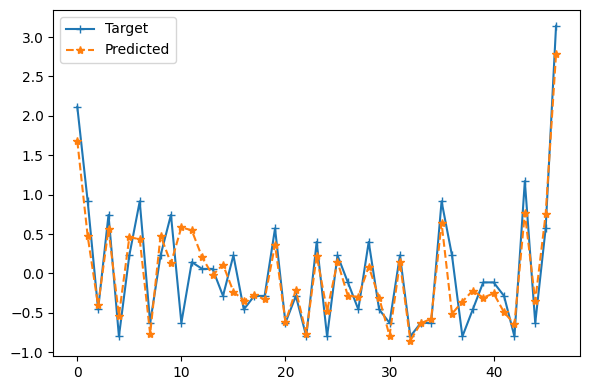

In [83]:
i = 4

fig, ax = plt.subplots(1,1, figsize=(6,4))
ax.plot(duration_arrays[i], "-+", label="Target")
ax.plot(model.predict(linguistic_arrays[i]), "--*", label="Predicted")


"""
ax.set_xticks(np.arange(len(test_phonemes)))
ax.set_xticklabels(test_phonemes)
ax.set_xlabel("Phoneme")
ax.set_ylabel("Duration (the number of frames)")
"""
ax.legend()

plt.tight_layout()